In [56]:
import pandas as pd
import itertools
from collections import Counter
import re
import networkx as nx
import matplotlib.pyplot as plt
import spacy
import os
import sys
from tqdm import tqdm
import math
import numpy as np

# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils

# Cargar datos

In [5]:
file_path = r"..\data\results\ciencia_chunks.xlsx"
fragmentos_ciencia = pd.read_excel(file_path, engine='openpyxl')

file_path2 = r"..\data\processed\corpus_cleaned.xlsx"
corpus_cleaned = pd.read_excel(file_path2, engine='openpyxl')

chunks_df = pd.read_parquet(r"..\data\processed\chunks.parquet")

# Preprocesamiento

In [9]:
# Cargar modelo y stopwords
nlp = spacy.load("es_core_news_sm")
stopwords = nlp.Defaults.stop_words

# Registrar tqdm para pandas apply
tqdm.pandas(desc="Tokenizando fragmentos científicos")

def limpiar_y_tokenizar(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    tokens = [t.lemma_ for t in nlp(texto) if t.is_alpha and t.lemma_ not in stopwords and len(t) > 2]
    return tokens

# Aplicar con barra de progreso
fragmentos_ciencia["tokens"] = fragmentos_ciencia["texto_chunk"].progress_apply(limpiar_y_tokenizar)

Tokenizando fragmentos científicos: 100%|██████████| 4287/4287 [02:24<00:00, 29.76it/s]


# Generar pares de coocurrencias por chunks

In [ ]:
# Frecuencia de cada palabra
todas_palabras = [w for lista in fragmentos_ciencia["tokens"] for w in lista]
freq_palabras  = pd.Series(todas_palabras).value_counts()

#palabras_excluir = set(freq_palabras.head(10).index)


palabras_excluir = {
    "colombia", "año", "país", "tiempo", "nacional", "gobierno", "social",
    "público", "personas", "sociedad", "mundo", "vida", "día"
}

palabras_excluir

{'año',
 'colombia',
 'día',
 'gobierno',
 'mundo',
 'nacional',
 'país',
 'personas',
 'público',
 'social',
 'sociedad',
 'tiempo',
 'vida'}

In [51]:
def generar_pares(tokens):
    """Devuelve todas las combinaciones únicas de palabras en un mismo fragmento."""
    tokens_filtrados = [t for t in set(tokens) if t not in palabras_excluir]

    return list(itertools.combinations(sorted(tokens_filtrados), 2))

# Crear lista global de pares
pares = []
for lista in fragmentos_ciencia["tokens"]:
    pares.extend(generar_pares(lista))

print(f"Total de pares generados: {len(pares):,}")

# Contar coocurrencias
coocurrencias = Counter(pares)

# Convertir a DataFrame
cooc_df = pd.DataFrame(
    [(w1, w2, count) for (w1, w2), count in coocurrencias.items()],
    columns=["palabra_1", "palabra_2", "frecuencia"]
).sort_values("frecuencia", ascending=False)

print("\nTop coocurrencias:")
print(cooc_df.head(20))

Total de pares generados: 21,727,919

Top coocurrencias:
        palabra_1   palabra_2  frecuencia
163756      deber  desarrollo         352
66764       deber       salud         332
17290       deber    política         328
43457       deber   económico         313
17306       deber      seguir         312
77875       deber     sistema         312
15580      cambio       deber         311
15838        caso       deber         308
135495      deber     recurso         307
70072      cambio   climático         307
3842        deber     persona         305
17294       deber     proceso         300
205858  ambiental       deber         299
3799        deber       forma         291
55396       deber     ejemplo         281
135481      deber      medida         269
17288       deber    permitir         267
17277       deber      llegar         267
258838      deber      humano         264
43452       deber       dejar         263


# Filtrar y visualizar red básica

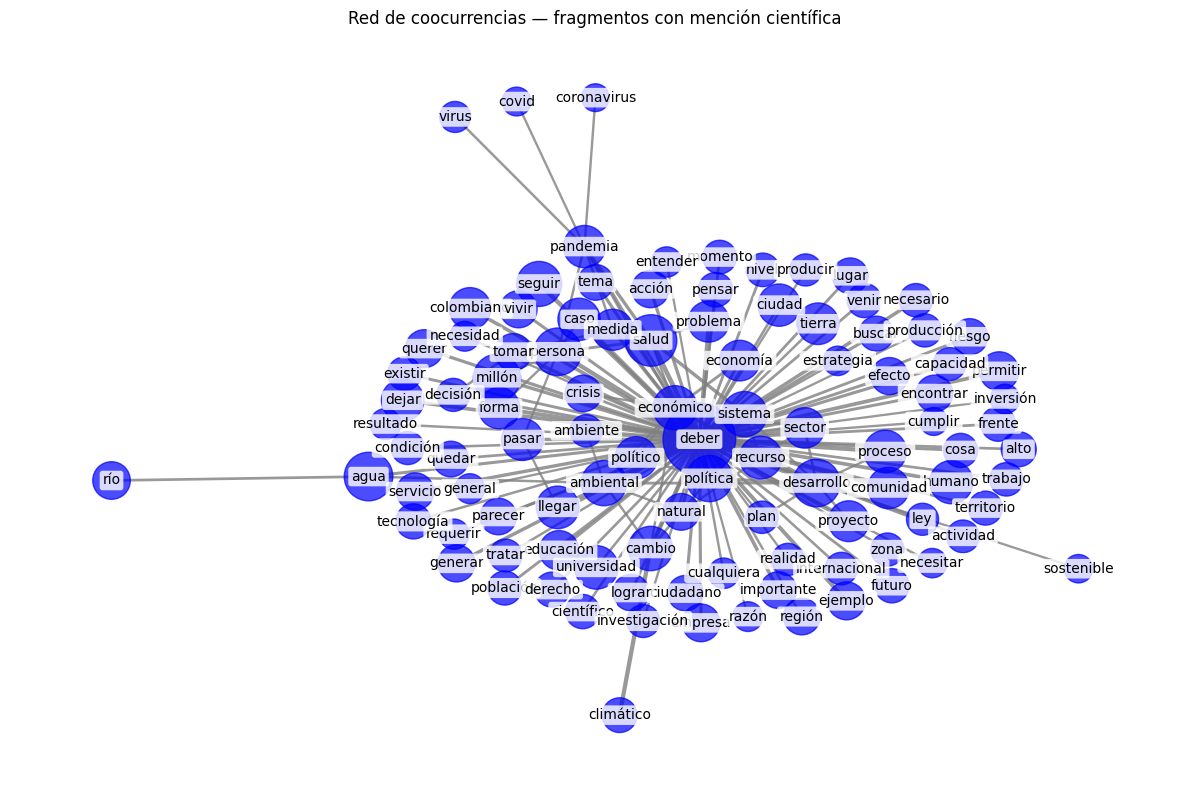

In [64]:
# Filtro opcional: palabras con al menos 20 coocurrencias
cooc_df_filtrado = cooc_df[cooc_df["frecuencia"] >= 20].head(150)

# Crear red
G = nx.from_pandas_edgelist(
    cooc_df_filtrado, 
    source="palabra_1", 
    target="palabra_2", 
    edge_attr="frecuencia"
)
# --- asignar frecuencia como atributo de cada nodo ---
nx.set_node_attributes(G, freq_palabras.to_dict(), "frecuencia")

# --- definir tamaño de nodo proporcional a frecuencia ---
# usa raíz cuadrada para que no haya nodos desproporcionados
#node_sizes = [np.sqrt(G.nodes[n]["frecuencia"]) * 10 for n in G.nodes()]
node_sizes = [G.nodes[n]["frecuencia"] * 1 for n in G.nodes()]



plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.3, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="blue", alpha=0.7)
nx.draw_networkx_edges(G, pos, width=[d["frecuencia"]/100 for (_,_,d) in G.edges(data=True)], edge_color="gray", alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=10,
                            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.8),
                            font_color='black')
plt.title("Red de coocurrencias — fragmentos con mención científica")
plt.axis("off")
plt.tight_layout()
plt.show()


# PMI

In [20]:
# Calcular frecuencia de palabras individuales
todas_palabras = [w for lista in fragmentos_ciencia["tokens"] for w in lista]
freq_palabras = Counter(todas_palabras)

# Calcular frecuencia de coocurrencias (pares únicos por chunk)
pares = []
for lista in fragmentos_ciencia["tokens"]:
    pares.extend(itertools.combinations(sorted(set(lista)), 2))
freq_pares = Counter(pares)

# Crear DataFrame
cooc_df = pd.DataFrame(
    [(w1, w2, count) for (w1, w2), count in freq_pares.items()],
    columns=["palabra_1", "palabra_2", "frecuencia_cooc"]
)

# Calcular PMI
total_chunks = len(fragmentos_ciencia)

def calcular_pmi(row):
    f_w1 = freq_palabras[row["palabra_1"]]
    f_w2 = freq_palabras[row["palabra_2"]]
    f_w1w2 = row["frecuencia_cooc"]

    # Probabilidades
    p_w1 = f_w1 / total_chunks
    p_w2 = f_w2 / total_chunks
    p_w1w2 = f_w1w2 / total_chunks

    # Evitar división por cero
    if p_w1 == 0 or p_w2 == 0 or p_w1w2 == 0:
        return 0
    return math.log2(p_w1w2 / (p_w1 * p_w2))

# Filtrar pares relevantes
#   - Evita palabras muy frecuentes (top 10)
#   - Evita pares con coocurrencia muy baja (<10)
palabras_excluir = set(pd.Series(todas_palabras).value_counts().head(10).index)
cooc_df = cooc_df[
    (cooc_df["palabra_1"].apply(lambda x: x not in palabras_excluir)) &
    (cooc_df["palabra_2"].apply(lambda x: x not in palabras_excluir)) &
    (cooc_df["frecuencia_cooc"] >= 10)
]

cooc_df["PMI"] = cooc_df.apply(calcular_pmi, axis=1)

# Ordenar por PMI descendente
cooc_df_sorted = cooc_df.sort_values("PMI", ascending=False)
display(cooc_df_sorted.head(20))

,palabra_1,palabra_2,frecuencia_cooc,PMI
2803762,fake,news,10,8.365313
941918,quo,statu,11,8.132867
2144328,homo,sapiens,10,7.758324
3819189,greta,thunberg,10,7.758324
62430,cabal,fernanda,10,7.517316
748046,hong,kong,11,7.437721
2165730,alexander,von,11,7.065753
919655,bang,big,12,7.043385
772344,queda,toque,19,7.037556
2330530,der,hammar,11,7.017390


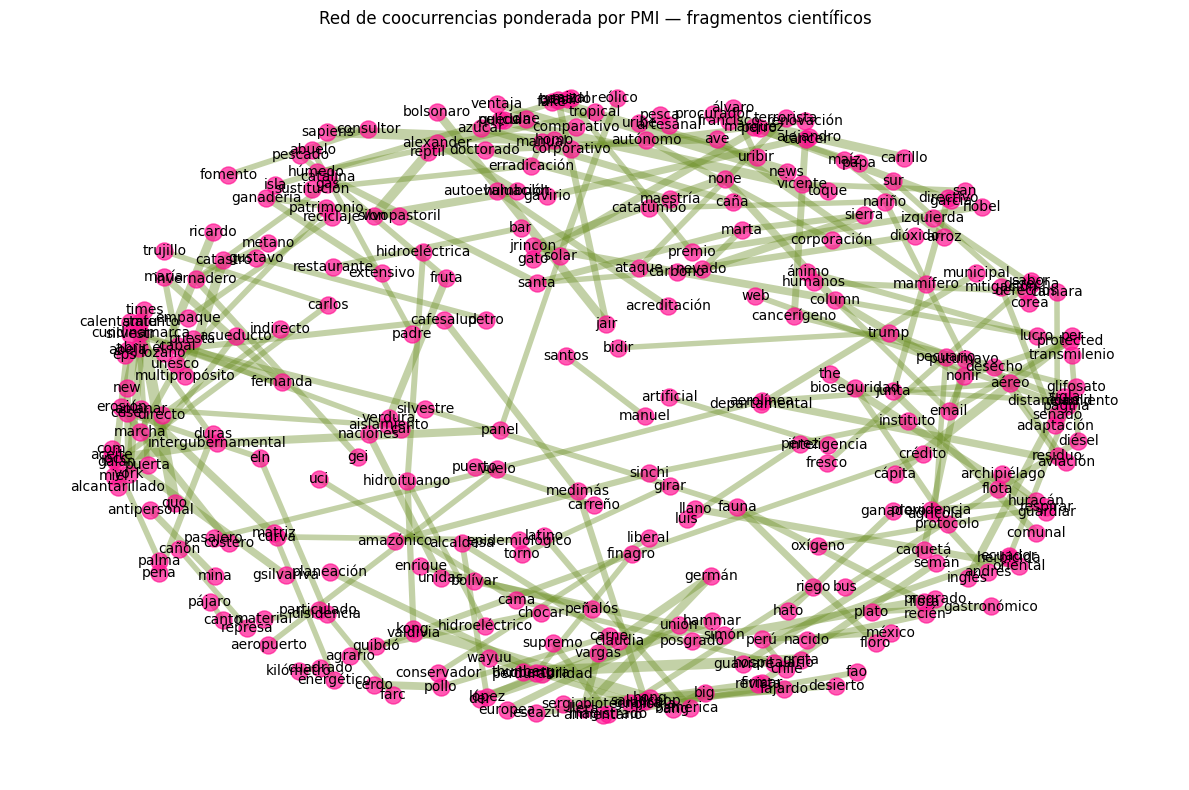

In [27]:
# Seleccionar los pares más fuertes (PMI alto y frecuencia razonable)
cooc_pmi_top = cooc_df_sorted[cooc_df_sorted["PMI"] > 2].head(200)

G = nx.from_pandas_edgelist(
    cooc_pmi_top,
    source="palabra_1",
    target="palabra_2",
    edge_attr="PMI"
)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.4, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=150, node_color="deeppink", alpha=0.7)
nx.draw_networkx_edges(G, pos, width=[d["PMI"] for (_,_,d) in G.edges(data=True)], alpha=0.4, edge_color="olivedrab")
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Red de coocurrencias ponderada por PMI — fragmentos científicos")
plt.axis("off")
plt.tight_layout()
plt.show()